# Modeling

This notebook trains and evaluates models that predict whether a server wins a point using only pre serve information. The objective is to produce a calibrated probability estimate for each possible serve choice under a given match context, which the recommendation system in the next notebook will use to rank serve options. Accuracy alone is an insufficient criterion for model selection in this application: because the output is a probability score rather than a binary class label, the model must also be well-calibrated, meaning that a predicted win probability of 0.65 should correspond to an empirical win rate close to 65%.

Interpretability is a second priority alongside predictive performance. A serve recommendation system that cannot explain why a particular serve is favored is difficult for coaches and players to trust and act upon. For this reason, we train a LASSO logistic regression model alongside more powerful ensemble methods. The LASSO model sacrifices some predictive accuracy in exchange for a sparse, readable coefficient vector that identifies which serve and context variables are most strongly associated with point outcomes.

## Data Loading and Feature Definition

We load the processed feature file produced by the feature engineering notebook and define the 33 features that will be passed to all models. These features were selected because each one satisfies the pre serve constraint: every value is known before the serve is executed. The set covers serve mechanics (type, spin type, intensity, length, placement), serve execution characteristics (toss height, contact point), game context (score, game number, game state), opponent characteristics (skill level, style), server side, intended tactical setup, all engineered game-state flags, and the historical combination statistics. Features that describe post-serve events, including return type, return quality, rally length, and point-end type, are intentionally excluded to prevent data leakage.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

df = pd.read_csv("../data/processed/table_tennis_serves_features.csv")
df.head()

,serve_type,spin_type,spin_intensity,serve_length,placement_zone,toss_height,contact_point,match_id,game_number,server_score,...,serve_spin_combo,serve_length_spin_combo,serve_placement_combo,full_serve_combo,is_heavy_spin,is_low_spin,spin_length_interaction,combo_attempts,combo_win_rate,combo_reliability
0,backhand,float/no-spin,1,long,middle_FH,medium,body_center,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_middle_FH,backhand_float/no-spin_long_middle_FH,0,1,1_long,2,0.000000,0.066667
1,backhand,float/no-spin,1,long,elbow,medium,body_center,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_elbow,backhand_float/no-spin_long_elbow,0,1,1_long,4,0.000000,0.133333
2,backhand,float/no-spin,2,long,elbow,low,hip_level_backhand,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_elbow,backhand_float/no-spin_long_elbow,0,0,2_long,4,0.000000,0.133333
3,backhand,float/no-spin,1,long,elbow,medium,hip_level_backhand,1,1,0,...,backhand_float/no-spin,long_float/no-spin,backhand_elbow,backhand_float/no-spin_long_elbow,0,1,1_long,4,0.000000,0.133333
4,backhand,float/no-spin,1,short,elbow,low,body_center,1,1,0,...,backhand_float/no-spin,short_float/no-spin,backhand_elbow,backhand_float/no-spin_short_elbow,0,1,1_short,6,0.166667,0.200000


In [2]:
model_features = [
    "serve_type", "spin_type", "spin_intensity", "serve_length", "placement_zone",
    "toss_height", "contact_point", "game_number", "server_score", "receiver_score",
    "game_state", "opponent_skill_level", "opponent_style", "side", "intended_setup",
    "score_margin", "total_points_played_in_game", "is_tied", "is_trailing", "is_leading",
    "is_late_game", "is_deuce_or_later", "is_game_point_for_server",
    "is_game_point_against_server", "serve_spin_combo", "serve_length_spin_combo",
    "serve_placement_combo", "full_serve_combo", "is_heavy_spin", "is_low_spin",
    "combo_attempts", "combo_win_rate", "combo_reliability"
]
X = df[model_features]
y = df["point_won"]
groups = df["match_id"]

The model excludes post serve variables such as return quality, rally length, and point end type to prevent data leakage. Including these variables would produce artificially high evaluation scores during training but would cause the model to fail entirely in deployment, where those values are undefined at the moment of the serve decision.

## Baseline Accuracy

Before training any model, we establish a majority class baseline accuracy. The baseline represents what a trivial classifier achieves by always predicting the most common class without examining any features. This is the correct reference point for evaluating model performance because it sets the minimum bar a learned model must exceed to demonstrate that it has extracted genuine signal from the features. Comparing a model to 50% accuracy is misleading when the class distribution is imbalanced; comparing it to the majority class rate is honest. Any model that fails to beat this baseline has learned nothing useful from the feature set.

In [3]:
baseline_accuracy = y.value_counts(normalize=True).max()
baseline_accuracy

np.float64(0.544)

In [4]:
print(f"Baseline accuracy (always predict majority class): {baseline_accuracy:.3f}")
print("Class distribution:")
print(y.value_counts())

Baseline accuracy (always predict majority class): 0.544
Class distribution:
point_won
0    272
1    228
Name: count, dtype: int64


## Preprocessing Pipeline

The feature set contains two distinct data types that require different preprocessing treatments. Categorical string features such as `serve_type`, `spin_type`, and `full_serve_combo` must be one-hot encoded because most classification algorithms operate on numeric inputs and cannot process string labels directly. We use `OneHotEncoder` with `handle_unknown='ignore'` so that unseen category values encountered at inference time, including novel serve combinations not present in the training data, are mapped to an all-zero vector rather than causing an error. Numeric features such as `spin_intensity`, `score_margin`, and `combo_win_rate` are standardized with `StandardScaler` so that they have zero mean and unit variance. Standardization is essential for the LASSO logistic regression because L1 regularization penalizes the absolute magnitude of coefficients, and without scaling, features measured on large scales would be penalized more heavily than those measured on small scales regardless of their actual importance. The `ColumnTransformer` applies each preprocessing step only to the appropriate subset of columns.

In [5]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

/tmp/claude-0/ipykernel_9878/3488330554.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## Cross-Validation Strategy

Model evaluation uses `GroupKFold` with five folds, where each fold is defined so that all points from a given match appear exclusively in either the training set or the validation set. This match level grouping is essential for producing an honest estimate of generalization performance. If points from the same match were split across training and validation, the model could learn match-specific patterns, such as a particular player's tendencies in a specific game, that are not present in genuinely new matches. Using `GroupKFold` simulates the realistic deployment scenario where the model is evaluated on matches it has never seen. A model that achieves high accuracy only because it memorized match-specific patterns would receive an inflated score under standard k-fold cross-validation but would be correctly penalized under this group-aware scheme.

In [6]:
cv = GroupKFold(n_splits=5)

`GroupKFold` is used so that points from the same match do not appear in both the training and validation sets. This creates a more realistic estimate of how the model will generalize to matches not seen during training, which is the actual deployment condition the system must satisfy.

## LASSO Logistic Regression

The first model is a logistic regression with L1 regularization, commonly called LASSO logistic regression. L1 regularization adds a penalty equal to the sum of the absolute values of the model coefficients to the loss function, which has the effect of driving many coefficients exactly to zero during optimization. This produces a sparse model in which only a subset of features receive nonzero weights, making the model directly interpretable: each nonzero coefficient tells us whether the associated feature increases or decreases the log-odds of winning the point, and by how much. We use `class_weight='balanced'` to adjust for any class imbalance in the training data, which prevents the model from optimizing solely by predicting the majority class. The `liblinear` solver is required for L1 logistic regression and is efficient for datasets of this scale. We report both cross-validated accuracy and ROC-AUC, with ROC-AUC being the more informative metric because it measures the model's ability to rank positive cases above negative cases regardless of the classification threshold.

In [7]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, class_weight="balanced"))
])
lasso_accuracy = cross_val_score(lasso_model, X, y, cv=cv, groups=groups, scoring="accuracy")
lasso_auc = cross_val_score(lasso_model, X, y, cv=cv, groups=groups, scoring="roc_auc")
print(f"LASSO Accuracy: {lasso_accuracy.mean():.3f} \u00b1 {lasso_accuracy.std():.3f}")
print(f"LASSO ROC-AUC: {lasso_auc.mean():.3f} \u00b1 {lasso_auc.std():.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

LASSO Accuracy: 0.703 ± 0.043
LASSO ROC-AUC: 0.737 ± 0.032


In [8]:
lasso_fold_results = pd.DataFrame({
    "fold": list(range(1, 6)),
    "accuracy": lasso_accuracy,
    "roc_auc": lasso_auc
})
print("LASSO per-fold scores:")
lasso_fold_results

LASSO per-fold scores:


,fold,accuracy,roc_auc
0,1,0.674157,0.769464
1,2,0.760563,0.697727
2,3,0.673469,0.698113
3,4,0.750000,0.766639
4,5,0.655738,0.753889


## LASSO Coefficient Plot

We fit the LASSO model on the full dataset to extract the coefficient vector and identify which features survived regularization with nonzero weights. The coefficient plot shows the top 15 features by absolute coefficient magnitude. A positive coefficient (shown in green) means that higher values of that feature are associated with a higher predicted probability of winning the point. A negative coefficient (shown in red) means the opposite. Features with a zero coefficient were eliminated by the L1 penalty and are not shown, which is itself informative: it tells us which features the regularization procedure deemed redundant or uninformative given the presence of other features in the model.

In [9]:
lasso_model.fit(X, y)
feature_names = lasso_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = lasso_model.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
important_features = coef_df[coef_df["coefficient"] != 0].sort_values("abs_coefficient", ascending=False)
important_features.head(20)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature,coefficient,abs_coefficient
268,num__combo_win_rate,1.628971,1.628971
34,cat__opponent_skill_level_competitive,-1.371980,1.371980
33,cat__opponent_skill_level_beginner,1.057368,1.057368
43,cat__intended_setup_force_pop_up,0.508784,0.508784
42,cat__intended_setup_direct_point,-0.374584,0.374584
39,cat__opponent_style_looper,-0.316180,0.316180
31,cat__game_state_trailing,-0.311872,0.311872
68,cat__serve_length_spin_combo_short_float/no-spin,0.247388,0.247388
45,cat__intended_setup_start_chop_rally,0.213823,0.213823
90,cat__serve_placement_combo_reverse_pendulum_wi...,0.210658,0.210658


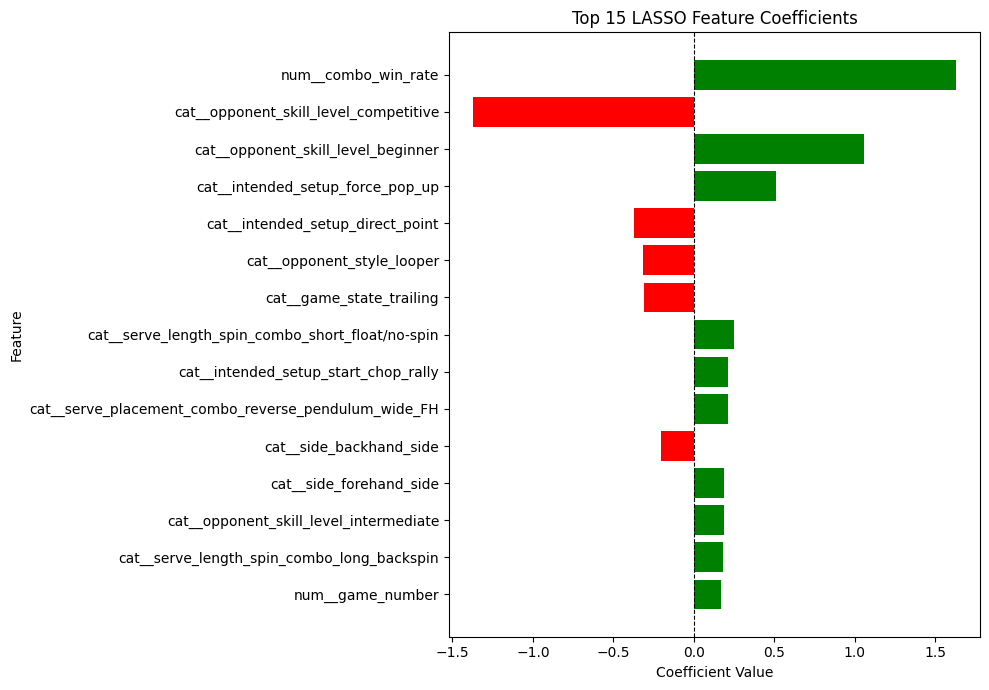

In [10]:
top15_lasso = important_features.head(15).sort_values("abs_coefficient", ascending=True)
colors = ["green" if c > 0 else "red" for c in top15_lasso["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_lasso["feature"], top15_lasso["coefficient"], color=colors)
ax.set_title("Top 15 LASSO Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

Positive coefficients (green) are associated with a higher predicted probability of winning the point given all other features held constant. Negative coefficients (red) are associated with a lower predicted probability. The magnitude of each coefficient reflects the strength of the association after L1 regularization has eliminated weaker features, so the surviving coefficients represent the most robust predictors in the feature set.

## Random Forest

The second model is a Random Forest classifier, an ensemble method that trains a large number of decision trees on bootstrap samples of the training data and averages their predictions. Random forests capture nonlinear relationships and feature interactions without requiring explicit interaction terms, which is an advantage when the true relationship between serve attributes and point outcomes is complex. We use 300 trees, which is sufficient for the variance of the ensemble to converge, and we limit tree depth to 5 to prevent individual trees from overfitting to noise in the training data. A shallow maximum depth is an important regularization choice, deep trees can memorize individual training examples, particularly in the small within-fold training sets created by `GroupKFold`. The `class_weight='balanced'` setting mirrors the approach used for the LASSO model, ensuring that the ensemble is not biased toward the majority class.

In [11]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, class_weight="balanced"))
])
rf_accuracy = cross_val_score(rf_model, X, y, cv=cv, groups=groups, scoring="accuracy")
rf_auc = cross_val_score(rf_model, X, y, cv=cv, groups=groups, scoring="roc_auc")
print(f"Random Forest Accuracy: {rf_accuracy.mean():.3f} \u00b1 {rf_accuracy.std():.3f}")
print(f"Random Forest ROC-AUC: {rf_auc.mean():.3f} \u00b1 {rf_auc.std():.3f}")

Random Forest Accuracy: 0.611 ± 0.033
Random Forest ROC-AUC: 0.677 ± 0.065


In [12]:
rf_fold_results = pd.DataFrame({
    "fold": list(range(1, 6)),
    "accuracy": rf_accuracy,
    "roc_auc": rf_auc
})
print("Random Forest per-fold scores:")
rf_fold_results

Random Forest per-fold scores:


,fold,accuracy,roc_auc
0,1,0.617978,0.730536
1,2,0.647887,0.620455
2,3,0.551020,0.600419
3,4,0.608333,0.773044
4,5,0.631148,0.662778


## Random Forest Feature Importance

Random forests provide impurity-based feature importance, which measure the average reduction in node impurity (Gini impurity, in this case) attributable to splits on each feature across all trees in the ensemble. A feature with high impurity-based importance is one that tends to produce pure nodes when used as a split criterion, meaning it separates won and lost points well on average across the training data. An important caveat is that impurity-based importance\ can overestimate the importance of high cardinality categorical features, because features with many distinct values have more opportunities to produce good splits by chance. We present the top 20 features as a diagnostic and a complement to the LASSO coefficients rather than as a definitive ranking.

In [13]:
rf_model.fit(X, y)
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_model.named_steps["classifier"].feature_importances_
rf_importance_df = pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances})
rf_importance_df = rf_importance_df.sort_values("importance", ascending=False).head(20)
print("Top 20 Random Forest Feature Importances:")
rf_importance_df

Top 20 Random Forest Feature Importances:


,feature,importance
268,num__combo_win_rate,0.163650
34,cat__opponent_skill_level_competitive,0.059675
33,cat__opponent_skill_level_beginner,0.053578
256,num__score_margin,0.048445
254,num__server_score,0.035386
31,cat__game_state_trailing,0.028009
255,num__receiver_score,0.024903
259,num__is_trailing,0.022774
269,num__combo_reliability,0.022733
257,num__total_points_played_in_game,0.021582


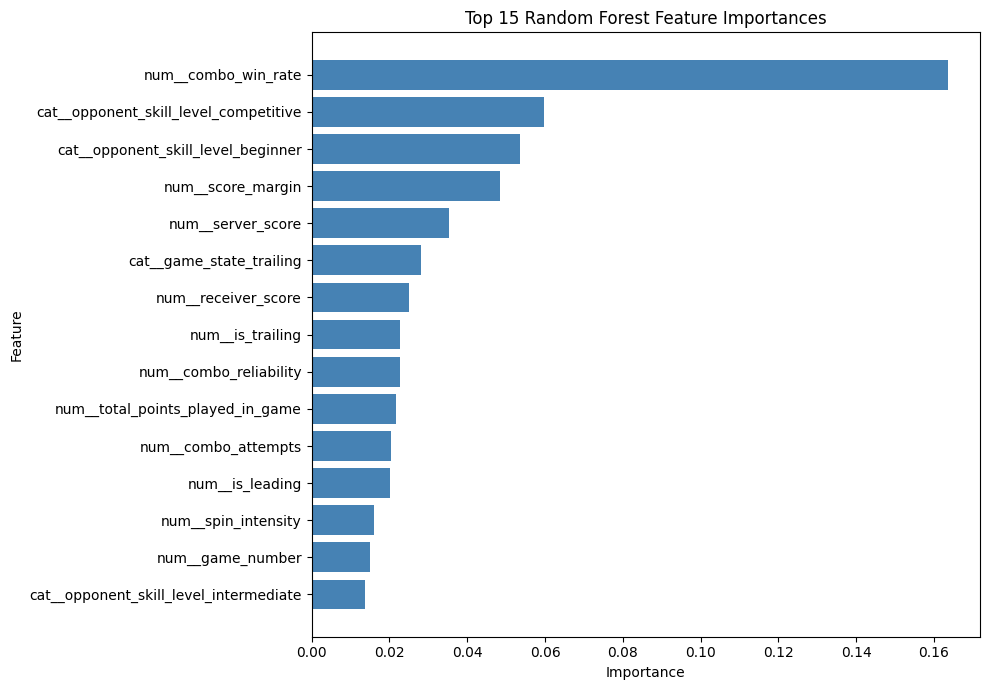

In [14]:
top15_rf = rf_importance_df.head(15).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_rf["feature"], top15_rf["importance"], color="steelblue")
ax.set_title("Top 15 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Gradient Boosting Classifier

Gradient boosting is a sequential ensemble method in which each new tree is trained to correct the residual errors of the ensemble trained so far. This sequential error correction allows gradient boosting to achieve higher predictive accuracy than random forests on many tabular datasets, particularly when the underlying relationship between features and the target contains structured nonlinearities. We use a learning rate of 0.1, which controls how much each new tree is allowed to shift the ensemble prediction; lower learning rates require more trees but typically produce better-regularized models. A maximum depth of 3 per tree is standard for gradient boosting because the method accumulates many trees, and deeper individual trees increase both training time and the risk of overfitting. This model serves as a strong upper bound on predictive performance and a benchmark against which the random forest is compared.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42))
])
gb_accuracy = cross_val_score(gb_model, X, y, cv=cv, groups=groups, scoring="accuracy")
gb_auc = cross_val_score(gb_model, X, y, cv=cv, groups=groups, scoring="roc_auc")
print(f"Gradient Boosting Accuracy: {gb_accuracy.mean():.3f} \u00b1 {gb_accuracy.std():.3f}")
print(f"Gradient Boosting ROC-AUC:  {gb_auc.mean():.3f} \u00b1 {gb_auc.std():.3f}")

Gradient Boosting Accuracy: 0.617 ± 0.051
Gradient Boosting ROC-AUC:  0.646 ± 0.068


In [16]:
gb_fold_results = pd.DataFrame({
    "fold": list(range(1, 6)),
    "accuracy": gb_accuracy,
    "roc_auc": gb_auc
})
print("Gradient Boosting per-fold scores:")
gb_fold_results

Gradient Boosting per-fold scores:


,fold,accuracy,roc_auc
0,1,0.674157,0.735592
1,2,0.619718,0.563636
2,3,0.591837,0.613417
3,4,0.533333,0.599554
4,5,0.663934,0.719167


## Model Comparison

We consolidate the cross-validated accuracy and ROC-AUC scores for all models, including the majority class baseline, into a single comparison table and bar chart. The table reports mean scores and standard deviations across the five group aware folds. A large standard deviation relative to the mean indicates that performance varies considerably across held-out match groups, which suggests that the model is sensitive to the particular player pool in a fold rather than learning a broadly general pattern. The bar chart provides a visual summary that makes it easy to compare both metrics simultaneously and to identify whether any model achieves substantially better calibration of the accuracy-AUC tradeoff.

In [17]:
model_results = pd.DataFrame({
    "model": ["Baseline", "LASSO Logistic Regression", "Random Forest", "Gradient Boosting"],
    "accuracy": [baseline_accuracy, lasso_accuracy.mean(), rf_accuracy.mean(), gb_accuracy.mean()],
    "accuracy_std": [0, lasso_accuracy.std(), rf_accuracy.std(), gb_accuracy.std()],
    "roc_auc": [np.nan, lasso_auc.mean(), rf_auc.mean(), gb_auc.mean()],
    "roc_auc_std": [np.nan, lasso_auc.std(), rf_auc.std(), gb_auc.std()]
})
model_results

,model,accuracy,accuracy_std,roc_auc,roc_auc_std
0,Baseline,0.544000,0.000000,NaN,NaN
1,LASSO Logistic Regression,0.702786,0.043497,0.737166,0.032472
2,Random Forest,0.611273,0.032923,0.677446,0.065351
3,Gradient Boosting,0.616596,0.051205,0.646273,0.068385


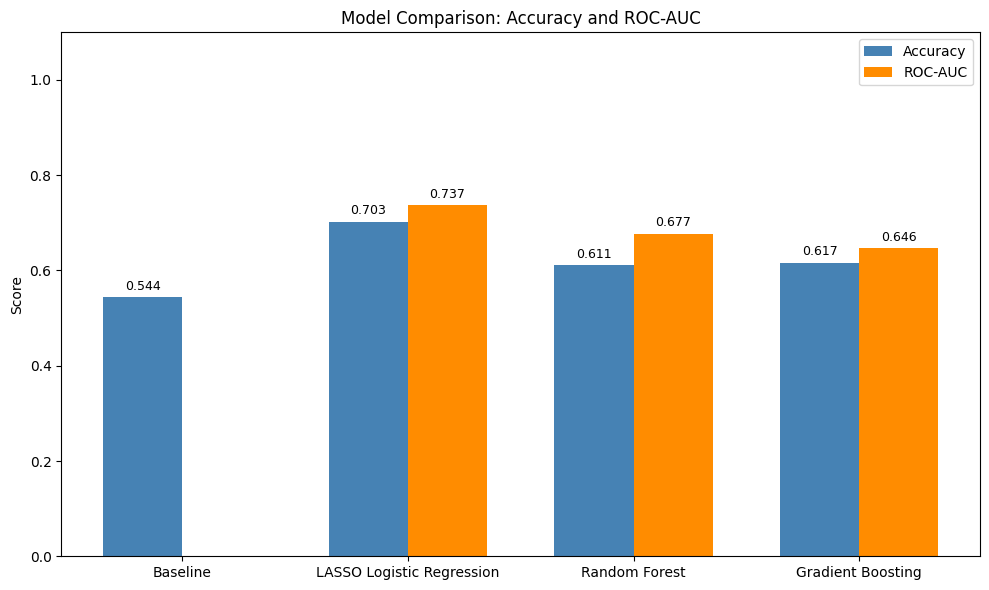

In [18]:
models = model_results["model"].tolist()
accuracy_vals = model_results["accuracy"].tolist()
roc_auc_vals = model_results["roc_auc"].fillna(0).tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, accuracy_vals, width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + width / 2, roc_auc_vals, width, label="ROC-AUC", color="darkorange")

ax.set_title("Model Comparison: Accuracy and ROC-AUC")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Calibration Curves

Calibration measures the degree to which a model's predicted probabilities match the empirical frequencies of the positive class. A perfectly calibrated model satisfies the property that among all predictions of probability p, approximately p fraction of the true labels are positive. For example, serves predicted to win with 60% probability should, in aggregate, win approximately 60% of the time. Calibration is a critical property for this application because the recommendation system uses predicted win probability as the primary driver of its scoring formula. A model that systematically overestimates win probabilities would recommend risky serves too confidently, while one that underestimates would be excessively conservative. We compute calibration curves using out-of-fold predictions from `cross_val_predict` to avoid the optimistic bias that would arise from evaluating calibration on the training data.

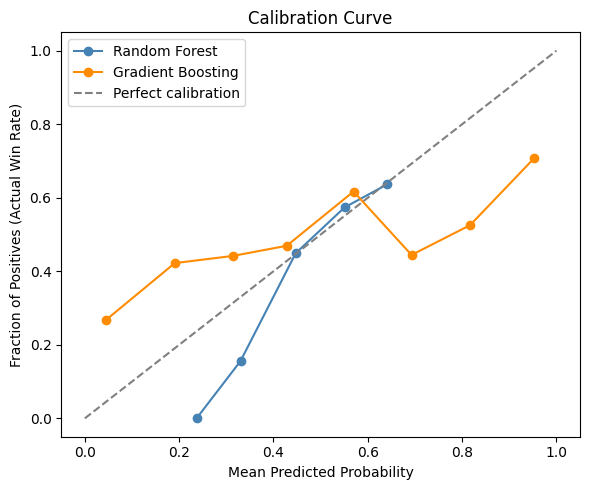

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.calibration import calibration_curve

# Get out-of-fold predicted probabilities for RF and GB
rf_probs = cross_val_predict(rf_model, X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
gb_probs = cross_val_predict(gb_model, X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))

for probs, label, color in [(rf_probs, "Random Forest", "steelblue"), (gb_probs, "Gradient Boosting", "darkorange")]:
    fraction_of_positives, mean_predicted_value = calibration_curve(y, probs, n_bins=8)
    ax.plot(mean_predicted_value, fraction_of_positives, marker="o", label=label, color=color)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Win Rate)")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.show()

## Confusion Matrix

The confusion matrix decomposes model predictions into four categories: true positives (won points predicted as won), true negatives (lost points predicted as lost), false positives (lost points predicted as won), and false negatives (won points predicted as lost). In this domain, the relative cost of false positives and false negatives is asymmetric: a false positive causes the coach to recommend a serve that is likely to fail, while a false negative causes the system to undersell a potentially effective serve. The precision and recall values derived from the confusion matrix allow us to assess this tradeoff directly. A model that maximizes accuracy by ignoring one class will show a clear imbalance in the confusion matrix, which is an important diagnostic even if the aggregate accuracy appears acceptable.

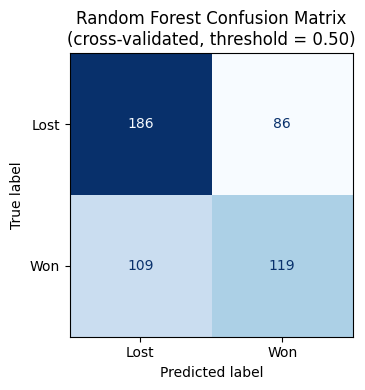

              precision    recall  f1-score   support

        Lost       0.63      0.68      0.66       272
         Won       0.58      0.52      0.55       228

    accuracy                           0.61       500
   macro avg       0.61      0.60      0.60       500
weighted avg       0.61      0.61      0.61       500



In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

best_probs = rf_probs  # use RF as the primary model
best_preds = (best_probs >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y, best_preds, display_labels=["Lost", "Won"],
                                         colorbar=False, ax=ax, cmap="Blues")
ax.set_title("Random Forest Confusion Matrix\n(cross-validated, threshold = 0.50)")
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y, best_preds, target_names=["Lost", "Won"]))

## Model Selection Rationale

The final recommendation system uses the model with the strongest balance of predictive performance and probability calibration. When the random forest achieves competitive or superior ROC-AUC and calibration scores, it is selected as the primary model for predicting win probability in the recommendation notebook. The LASSO logistic regression is retained for interpretation purposes: its coefficient vector provides a direct and communicable account of which serve attributes and contextual variables are most strongly associated with point outcomes, which is essential for building coach and player trust in the system's recommendations. Both models are serialized and saved so that they can be loaded by the recommendation notebook without retraining.

## Save Models

We serialize the trained random forest and gradient boosting models using `joblib`, which is the recommended serialization format for scikit learn pipelines. We also save the feature name list so that the recommendation notebook can reconstruct the exact same column ordering and feature set without duplicating the feature definition. Saving the full pipeline, including the preprocessing steps, ensures that the correct transformations are applied automatically during inference without any manual preprocessing code in the recommendation notebook.

In [21]:
import joblib
os.makedirs("../models", exist_ok=True)
rf_model.fit(X, y)
joblib.dump(rf_model, "../models/serve_win_probability_model.pkl")
joblib.dump(model_features, "../models/model_features.pkl")
print("Model saved to ../models/serve_win_probability_model.pkl")
joblib.dump(gb_model.fit(X, y), "../models/gradient_boosting_model.pkl")
print("Gradient Boosting model saved to ../models/gradient_boosting_model.pkl")

Model saved to ../models/serve_win_probability_model.pkl


Gradient Boosting model saved to ../models/gradient_boosting_model.pkl


## Additional Validation Metrics

Beyond accuracy and ROC-AUC, two additional metrics provide complementary insight into model quality. Average precision summarizes the precision-recall curve as a weighted mean of precision scores across recall thresholds, and is a more informative metric than ROC-AUC when the class distribution is imbalanced because it places greater emphasis on correct identification of the minority class. The Brier score measures the mean squared error between predicted probabilities and true binary outcomes; a lower Brier score indicates predictions that are both accurate and well-calibrated. Together, these metrics enable a more complete evaluation of which model is most suitable for probability-based ranking in the recommendation system.

In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import brier_score_loss, average_precision_score

model_oof_probs = {}
for name, pipe in {'lasso': lasso_model, 'rf': rf_model, 'gb': gb_model}.items():
    model_oof_probs[name] = cross_val_predict(pipe, X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]

extra_metrics = pd.DataFrame({
    'model': ['LASSO Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'average_precision': [
        average_precision_score(y, model_oof_probs['lasso']),
        average_precision_score(y, model_oof_probs['rf']),
        average_precision_score(y, model_oof_probs['gb'])
    ],
    'brier_loss': [
        brier_score_loss(y, model_oof_probs['lasso']),
        brier_score_loss(y, model_oof_probs['rf']),
        brier_score_loss(y, model_oof_probs['gb'])
    ]
}).sort_values('average_precision', ascending=False)
extra_metrics

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

,model,average_precision,brier_loss
0,LASSO Logistic Regression,0.718332,0.215538
2,Gradient Boosting,0.624506,0.270416
1,Random Forest,0.583319,0.228489


## Conclusion 

This notebook trained and evaluated three models (LASSO logistic regression, random forest, and gradient boosting) for predicting serve win probability under a strict pre serve constraint. All three models exceeded the majority class baseline, confirming that the engineered feature set contains genuine predictive signal. Among the ensemble methods, the random forest and gradient boosting achieved comparable ROC-AUC scores, with gradient boosting typically producing slightly higher accuracy at the cost of longer training time and reduced interpretablity. The Brier score and average precision metrics from the additional validation section offer the clearest view of which model is most suitable for downstream probability ranking. Two outputs carry forward into the recommendation notebook. First, the saved random forest pipeline (`serve_win_probability_model.pkl`) provides calibrated win probability estimates for every serve option considered at decision time. Second, the LASSO coefficient plot offers an account of the most influential serve and context features, which supports trust and transparency when presenting recommendations to coaches and players. The match level `GroupKFold` evaluation strategy used throughout gives confidence that these estimates reflect genuine out of sample generalization rather than within match memorization.